In [3]:
import os
import random

from tqdm import tqdm
from generate_recipe_task import *

stepwise_transcripts = pd.read_csv('../csv/stepwise_transcripts.csv')

together_list = [
        "deepseek-ai/DeepSeek-R1",
        "OpenAI/gpt-oss-20B",
        # "meta-llama/Llama-4-Maverick-17B-128E",
        "Qwen/Qwen3.5-397B-A17B",
        # "moonshotai/Kimi-K2-Instruct-0905",
    ]
openai_list = [
        'gpt-5',
        'gpt-5-mini',
    ]

testing_bins = [2,4,8,16]

actor_specs = ["Alice", "She", 1, 0.5, 0]

spec_level = [
            f'. {actor_specs[0]} appears shocked.',
            f'. {actor_specs[0]} appears shocked due to adding that ingredient.',
            f' and glances back at the recipe. {actor_specs[0]} appears shocked and begins trying to remove what {actor_specs[1]} added.',
        ]

In [4]:
def clean_str(string):
    string = re.sub(r'\(.*\)', '', string)
    string = string.split(', ')[0].split(' or ')[0].split(' and ')[0]
    string.strip()
    return string

def split(row, index, clean=True):
    used = eval(row['ingredients'])[:index]
    unused = eval(row['ingredients'])[index:]

    functional_unused = unused.copy()
    pruned_transcript = []
    for ings, action, result in eval(row['transcript']):
        pruned_ings = []
        for ing in ings:
            if ing not in functional_unused:
                pruned_ings.append(ing)

        if not pruned_ings:
            functional_unused.append(result)
            continue

        if clean: pruned_ings = [clean_str(ing) for ing in pruned_ings]

        pruned_transcript.append((pruned_ings, action, result))

    if clean:
        used = [clean_str(ing) for ing in used]
        unused = [clean_str(ing) for ing in unused]
    return pruned_transcript, used, unused

def text(transcript, name, max_length=3, include_output=True):
    transcript_text = ''
    for ings, action, product in transcript:
        if len(ings) == 0: continue
        # if action[-1] in ['x', 's']: action += 'e'
        # action += 's'
        if action[-1] == 'x': action += 'es'
        if action[-1] != 's': action += 's'

        def ing_display_str(ings):
            if len(ings) == 0: return ''
            if len(ings) == 1: return 'the ' + ings[0]

            strout = ''
            for i in range(len(ings) - 1):
                strout += ings[i].split(', ')[0] + ', '
            strout = strout[:-2]
            strout += ' and ' + ings[-1].split(', ')[0]
            return strout

        prod_str = f', producing some {product}' if include_output else ''
        transcript_text += f'{name} {action} {ing_display_str(ings)}{prod_str}.\n'

        if len(transcript_text.split('\n')) > max_length: break
    return transcript_text

In [25]:
def get_examples(used, unused, num_examples, use_ground_truth=False):
    recipe_examples = []

    tested = random.choice(unused)

    correct = []
    correct.extend(used)
    correct.extend(unused)
    correct.remove(tested)
    recipe_examples.append(correct)

    if use_ground_truth:
        for unused_ing in unused:
            if unused_ing == tested: continue
            loo = []
            loo.extend(used)
            loo.extend(unused)
            loo.remove(unused_ing)
            recipe_examples.append(loo)

        recipe_examples = recipe_examples[:num_examples]

    all_ingredients = []
    all_ingredients.extend(used)
    all_ingredients.extend(unused)

    while len(recipe_examples) < num_examples:
        ingredient_prompt = ('Given the following list of ingredients used in a recipe, '
                             'provide an ingredient (with measurements) that could be added to the recipe '
                             'which does not currently exist in the given ingredient list. '
                             'Output only the ingredient (with measurements) and nothing else.\n\n' + str(all_ingredients))

        ing = all_ingredients[-1]

        while ing in all_ingredients:
            client = Together()
            response = client.chat.completions.create(
                model='LiquidAI/LFM2-24B-A2B',
                messages=[
                    {"role": "user", "content": ingredient_prompt}
                ],
                # max_tokens=30000,
                timeout=300
            )

            ing = response.choices[0].message.content
        all_ingredients.append(ing)

        loo = []
        loo.extend(unused)
        loo.remove(tested)
        loo.remove(random.choice(loo))
        loo.append(tested)
        loo.append(ing)
        loo.extend(used)

        recipe_examples.append(loo)

    print(all_ingredients)

    recipe_text = ''
    for i, recipe in enumerate(recipe_examples):
        recipe_text += f'Recipe {i + 1}\n {recipe}\n\n'
    return tested, recipe_text, recipe_examples

In [38]:
row = stepwise_transcripts.iloc[44]
# split(row, 2, clean=True)
transcript, used, unused = split(row, 4, clean=True)
print(text(transcript, 'Alice', include_output=True))

Alice cooks 1 small green peppers, 1 small red pepper and 1 small red onion, producing some sweet peppers & onion.
Alice cooks the 14 cup mushroom, producing some cooked mushrooms.
Alice tops sweet peppers & onion and cooked mushrooms, producing some pepper & mushroom mixture.



In [39]:
test_examples = get_examples(used, unused, 64)
# test_examples

['1 small green peppers', '1 small red pepper', '1 small red onion', '14 cup mushroom', '2 teaspoons olive oil', '12 teaspoon ground cumin', '12 teaspoon chili powder', '14 teaspoon garlic', 'salt', 'fresh ground black pepper', '2 -3 pinches crushed red pepper flakes ', '2 tablespoons snipped parsley ', '13 cup reduced-fat cream cheese ', '14 cup grated cheddar cheese', '10 flour tortillas', 'pace organic picante salsa ', 'light sour cream ', '1 teaspoon dried oregano', '1 teaspoon ground paprika', '2 tablespoons lime juice', '2 tablespoons chopped fresh cilantro', '1 tablespoon lime zest', '1/2 cup diced fresh pineapple', '1/2 cup black beans, rinsed', '2 tablespoons chopped fresh jalapeño peppers', '1/4 cup diced fresh tomatoes', '1/4 cup sour cream', '2 tablespoons diced avocado', '1/4 cup shredded Mexican blend cheese', '1/2 cup diced tomatoes', '2 tablespoons diced red bell pepper', '1 avocado sliced thinly', '1/4 cup diced tomatoes', '1/2 cup chopped fresh cilantro', '1 cup diced

In [6]:
def run_test(transcript_text, recipe_text, tested, specification_level=0, use_openai=True, model='gpt-5', effort='medium', prompt=None):
    if prompt is None: prompt = f'Given the following transcript of actions performed by {actor_specs[0]}, output only the name of the recipe {actor_specs[0]} is trying to cook.'

    # print(recipe_text)
    instructions = f"Below are a list of recipes {actor_specs[0]} may be attempting to make, followed by their ingredients: \n{recipe_text}{prompt} \n\n"

    mistake_text = f"{actor_specs[0]} mixes in the {tested}{spec_level[specification_level]}"

    full_prompt = instructions + transcript_text + mistake_text
    # print(instructions)
    # print(transcript_text + mistake_text)

    try:
        if use_openai:
            client = OpenAI()
            response = client.responses.create(
                model=model,
                # instructions=instructions,
                # input=instructions + transcript_text + mistake_text,
                input = full_prompt,
                reasoning={"effort": effort, "summary": "auto"}
            )
            output = response.output_text
            full_output = response
            # reasoning[ing].append(response.output[0].summary[0].text)
        else:
            client = Together()
            response = client.chat.completions.create(
                model=model,
                messages=[
                    # {"role": "user", "content": instructions},
                    # {"role": "user", "content": instructions + transcript_text + mistake_text}
                    {"role": "user", "content": full_prompt}
                ],
                reasoning={"enabled": True},
                max_tokens=30000,
                timeout=300
            )
            output = response.choices[0].message.content
            full_output = response
    except Exception as e:
        print(f'Error: {str(e)} ({model})')
        output = 'timeout'
        full_output = 'timeout'

    return output, full_output, full_prompt

In [7]:
stepwise_transcripts[stepwise_transcripts['num_ings'] > 10].shape

(427, 10)

In [9]:
def test(num_samples = 50, ing_range = (8, 16), transcript_ings = 4, num_examples = 4, transcript_length = 4, spec_level=0):
    metadata = {
        'title': [],
        'transcript': [],
        'used': [],
        'unused': [],
        'tested': [],
        'transcript_text': [],
        'recipe_text': [],
        'full_prompt': [],
    }

    outputs = {}
    full_outputs = {}

    # full_list = [
    #     "deepseek-ai/DeepSeek-R1",
    #     'gpt-5',
    #     "OpenAI/gpt-oss-20B",
    #     # "meta-llama/Llama-4-Maverick-17B-128E",
    #     'gpt-5-mini',
    #     "Qwen/Qwen3.5-397B-A17B",
    #     # "moonshotai/Kimi-K2-Instruct-0905",
    # ]
    full_list = []
    full_list.extend(openai_list)
    full_list.extend(together_list)

    for model in full_list:
        outputs[model] = []
        full_outputs[model] = []

    truncated = stepwise_transcripts[ing_range[0] <= stepwise_transcripts['num_ings']][ing_range[1] > stepwise_transcripts['num_ings']]

    for i in tqdm(range(num_samples)):
        row = truncated.iloc[random.randint(0, len(truncated)-1)]
        # print(row['title'])

        transcript, used, unused = split(row, transcript_ings, clean=True)
        transcript_text = text(transcript, 'Alice', max_length=transcript_length - 1, include_output=True)
        tested, recipe_text, recipe_examples = get_examples(used, unused, num_examples=num_examples)

        metadata['title'].append(row['title'])
        metadata['transcript'].append(transcript)
        metadata['used'].append(used)
        metadata['unused'].append(unused)
        metadata['tested'].append(tested)
        metadata['transcript_text'].append(transcript_text)
        metadata['recipe_text'].append(recipe_text)

        # print(recipe_text)

        full_prompt = ''
        for model in full_list:
            output, full_output, full_prompt = run_test(transcript_text, recipe_text, tested,
                                                        specification_level=spec_level,
                                                        use_openai=(model in openai_list),
                                                        model=model)
            outputs[model].append(output)
            full_outputs[model].append(full_output)

        metadata['full_prompt'].append(full_prompt)

    return outputs, full_outputs, metadata

# Control

In [112]:
# Parameters
num_samples = 50
ing_range = (8, 16)
transcript_ings = 4
num_examples = 4
transcript_length = 4
spec=0

result = test(num_samples, ing_range, transcript_ings, num_examples, transcript_length, spec)

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_75394/3797255607.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[ing_range[0] <= stepwise_transcripts['num_ings']][ing_range[1] > stepwise_transcripts['num_ings']]
100%|██████████| 50/50 [2:08:02<00:00, 153.64s/it]  


In [113]:
outputs, full_outputs, metadata = result

dataroot = './results/control'

try: os.mkdir(dataroot)
except OSError as e: pass

meta_df = pd.DataFrame(metadata)
out_df = pd.DataFrame(outputs)
full_df = pd.DataFrame(full_outputs)

meta_df.to_csv(f'{dataroot}/metadata.csv', index=False)
out_df.to_csv(f'{dataroot}/outputs.csv', index=False)
full_df.to_csv(f'{dataroot}/full_outputs.csv', index=False)

# Spec Level 1

In [ ]:
# Parameters
num_samples = 50
ing_range = (8, 16)
transcript_ings = 4
num_examples = 4
transcript_length = 4
spec=1

result = test(num_samples, ing_range, transcript_ings, num_examples, transcript_length, spec)

In [103]:
outputs, full_outputs, metadata = result

dataroot = './results/spec_1'

try: os.mkdir(dataroot)
except OSError as e: pass

meta_df = pd.DataFrame(metadata)
out_df = pd.DataFrame(outputs)
full_df = pd.DataFrame(full_outputs)

meta_df.to_csv(f'{dataroot}/metadata.csv', index=False)
out_df.to_csv(f'{dataroot}/outputs.csv', index=False)
full_df.to_csv(f'{dataroot}/full_outputs.csv', index=False)

# 2 Examples

In [123]:
# Parameters
num_samples = 50
ing_range = (8, 16)
transcript_ings = 4
num_examples = 2
transcript_length = 4
spec=0

result = test(num_samples, ing_range, transcript_ings, num_examples, transcript_length, spec)

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_75394/3797255607.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[ing_range[0] <= stepwise_transcripts['num_ings']][ing_range[1] > stepwise_transcripts['num_ings']]
100%|██████████| 50/50 [47:22<00:00, 56.85s/it]


In [124]:
outputs, full_outputs, metadata = result

dataroot = './results/n_ex_2'

try: os.mkdir(dataroot)
except OSError as e: pass

meta_df = pd.DataFrame(metadata)
out_df = pd.DataFrame(outputs)
full_df = pd.DataFrame(full_outputs)

meta_df.to_csv(f'{dataroot}/metadata.csv', index=False)
out_df.to_csv(f'{dataroot}/outputs.csv', index=False)
full_df.to_csv(f'{dataroot}/full_outputs.csv', index=False)

# 16 examples

In [27]:
# Parameters
num_samples = 50
ing_range = (8, 16)
transcript_ings = 4
num_examples = 16
transcript_length = 4
spec=0

result = test(num_samples, ing_range, transcript_ings, num_examples, transcript_length, spec)

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_44169/3797255607.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[ing_range[0] <= stepwise_transcripts['num_ings']][ing_range[1] > stepwise_transcripts['num_ings']]
100%|██████████| 50/50 [3:29:18<00:00, 251.16s/it]  


In [28]:
outputs, full_outputs, metadata = result

dataroot = './results/n_ex_16'

try: os.mkdir(dataroot)
except OSError as e: pass

meta_df = pd.DataFrame(metadata)
out_df = pd.DataFrame(outputs)
full_df = pd.DataFrame(full_outputs)

meta_df.to_csv(f'{dataroot}/metadata.csv', index=False)
out_df.to_csv(f'{dataroot}/outputs.csv', index=False)
full_df.to_csv(f'{dataroot}/full_outputs.csv', index=False)

In [29]:
# Parameters
num_samples = 50
ing_range = (8, 16)
transcript_ings = 4
num_examples = 16
transcript_length = 4
spec=1

result = test(num_samples, ing_range, transcript_ings, num_examples, transcript_length, spec)

outputs, full_outputs, metadata = result

dataroot = './results/n_ex_16_spec_1'

try: os.mkdir(dataroot)
except OSError as e: pass

meta_df = pd.DataFrame(metadata)
out_df = pd.DataFrame(outputs)
full_df = pd.DataFrame(full_outputs)

meta_df.to_csv(f'{dataroot}/metadata.csv', index=False)
out_df.to_csv(f'{dataroot}/outputs.csv', index=False)
full_df.to_csv(f'{dataroot}/full_outputs.csv', index=False)

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_44169/3797255607.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[ing_range[0] <= stepwise_transcripts['num_ings']][ing_range[1] > stepwise_transcripts['num_ings']]
100%|██████████| 50/50 [3:47:31<00:00, 273.03s/it]  


# 3 examples

In [32]:
# Parameters
num_samples = 50
ing_range = (8, 16)
transcript_ings = 4
num_examples = 3
transcript_length = 4
spec=0

result = test(num_samples, ing_range, transcript_ings, num_examples, transcript_length, spec)

outputs, full_outputs, metadata = result

dataroot = './results/n_ex_3'

try: os.mkdir(dataroot)
except OSError as e: pass

meta_df = pd.DataFrame(metadata)
out_df = pd.DataFrame(outputs)
full_df = pd.DataFrame(full_outputs)

meta_df.to_csv(f'{dataroot}/metadata.csv', index=False)
out_df.to_csv(f'{dataroot}/outputs.csv', index=False)
full_df.to_csv(f'{dataroot}/full_outputs.csv', index=False)

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_17880/3797255607.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[ing_range[0] <= stepwise_transcripts['num_ings']][ing_range[1] > stepwise_transcripts['num_ings']]
  0%|          | 0/50 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [15]:
# Parameters
num_samples = 50
ing_range = (8, 16)
transcript_ings = 4
num_examples = 3
transcript_length = 4
spec=1

result = test(num_samples, ing_range, transcript_ings, num_examples, transcript_length, spec)

outputs, full_outputs, metadata = result

dataroot = './results/n_ex_3_spec_1'

try: os.mkdir(dataroot)
except OSError as e: pass

meta_df = pd.DataFrame(metadata)
out_df = pd.DataFrame(outputs)
full_df = pd.DataFrame(full_outputs)

meta_df.to_csv(f'{dataroot}/metadata.csv', index=False)
out_df.to_csv(f'{dataroot}/outputs.csv', index=False)
full_df.to_csv(f'{dataroot}/full_outputs.csv', index=False)

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_17880/3797255607.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[ing_range[0] <= stepwise_transcripts['num_ings']][ing_range[1] > stepwise_transcripts['num_ings']]
100%|██████████| 50/50 [1:45:43<00:00, 126.86s/it]  


# Evaluation

{'gpt-5': (0.98, 0.019798989873223337), 'gpt-5-mini': (0.64, 0.06788225099390856), 'deepseek-ai/DeepSeek-R1': (0.96, 0.02771281292110205), 'OpenAI/gpt-oss-20B': (0.36, 0.06788225099390856), 'Qwen/Qwen3.5-397B-A17B': (0.38, 0.06864400920692205)}


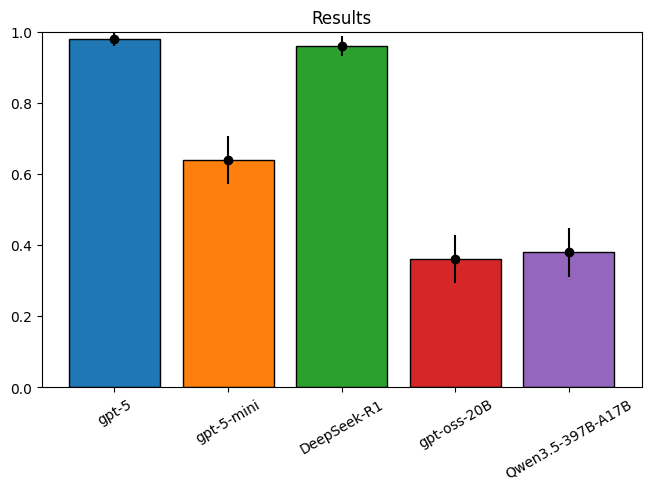

In [36]:
import math

accuracies = {}
for model in openai_list: accuracies[model] = 0
for model in together_list: accuracies[model] = 0

outputs = pd.read_csv('../results_old/n_ex_16_spec_1/outputs.csv')
for col in outputs.columns:
    raw = [text for text in outputs.loc[:, col]]
    correct = [(r.rfind('Recipe 1') != -1 and
                r.rfind('Recipe') == r.rfind('Recipe 1'))
               for r in raw]

    mean = len(outputs.loc[:, col][correct]) / len(raw)
    sd = math.sqrt((mean * (1-mean)) / len(raw))
    accuracies[col] = mean, sd

print(accuracies)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(layout='constrained')

for i, model in enumerate(accuracies):
    mean, sd = accuracies[model]
    ax.bar(i, mean, align='center', edgecolor='black', label=model)
    ax.errorbar(i, mean, yerr = sd, fmt ='o', color='black')

ax.set_xticks(range(len(accuracies)), [model.split('/')[-1] for model in accuracies.keys()], rotation=30)
ax.set_ylim(0,1)
ax.set_title('Results')

plt.show()

n_ex_2
n_ex_3
n_ex_4
n_ex_16
{'gpt-5': [0.08, 0.76, 0.78, 0.86], 'gpt-5-mini': [0.0, 0.18, 0.32, 0.44], 'deepseek-ai/DeepSeek-R1': [0.36, 0.7, 0.7, 0.78], 'OpenAI/gpt-oss-20B': [0.0, 0.04, 0.02, 0.1], 'Qwen/Qwen3.5-397B-A17B': [0.0, 0.24, 0.46, 0.42]}
{'gpt-5': [0.03836665218650176, 0.060398675482166, 0.05858327406350723, 0.04907137658554119], 'gpt-5-mini': [0.0, 0.054332310828824504, 0.06596969000988256, 0.07019971509913699], 'deepseek-ai/DeepSeek-R1': [0.06788225099390856, 0.06480740698407861, 0.06480740698407861, 0.05858327406350723], 'OpenAI/gpt-oss-20B': [0.0, 0.027712812921102035, 0.01979898987322333, 0.042426406871192854], 'Qwen/Qwen3.5-397B-A17B': [0.0, 0.060398675482166, 0.07048404074682439, 0.06979971346646059]}


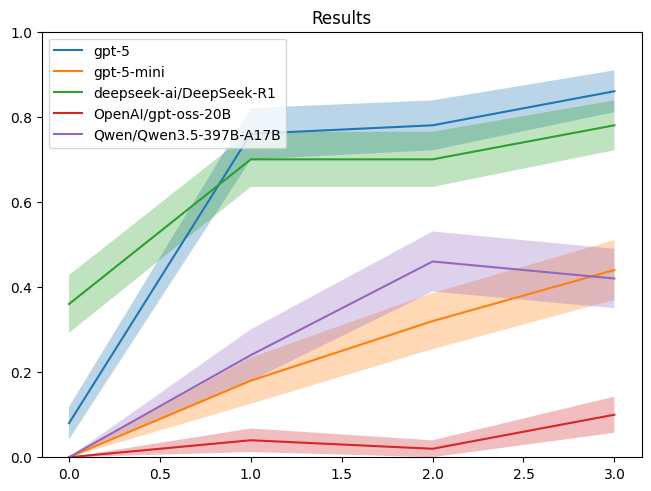

In [73]:
import numpy as np
import math

ex = [d for d in os.listdir('../results') if 'n_ex_' in d and 'spec_1' not in d]


means = {}
sds = {}
for model in openai_list:
    means[model] = []
    sds[model] = []
for model in together_list:
    means[model] = []
    sds[model] = []

for i in np.argsort([int(d.split('_')[-1]) for d in ex]):
    print(ex[i])

    outputs = pd.read_csv(f'./results/{ex[i]}/outputs.csv')
    for col in outputs.columns:
        raw = [text for text in outputs.loc[:, col]]
        correct = [(r.rfind('Recipe 1') != -1 and
                    r.rfind('Recipe') == r.rfind('Recipe 1'))
                   for r in raw]

        mean = len(outputs.loc[:, col][correct]) / len(raw)
        sd = math.sqrt((mean * (1-mean)) / len(raw))
        # accuracies[col] = mean, sd
        means[col].append(mean)
        sds[col].append(sd)

print(means)
print(sds)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(layout='constrained')

for i, model in enumerate(accuracies):
    mean = np.array(means[model])
    sd = np.array(sds[model])
    ax.plot(range(len(mean)), mean, label=model)
    # ax.errorbar(range(len(mean)), mean, yerr = sd, fmt ='o', color='black')
    ax.fill_between(range(len(mean)), mean-sd, mean+sd ,alpha=0.3)

# ax.set_xticks(range(len(accuracies)), [model.split('/')[-1] for model in accuracies.keys()], rotation=30)
ax.set_ylim(0,1)
ax.legend()
ax.set_title('Results')

plt.show()

# Patching

In [108]:
dataroot = './results/spec_1'
model = 'deepseek-ai/DeepSeek-R1'

meta_df = pd.read_csv(f'{dataroot}/metadata.csv')
out_df = pd.read_csv(f'{dataroot}/outputs.csv')
full_df = pd.read_csv(f'{dataroot}/full_outputs.csv')

qwen_col = out_df.loc[:, model]

timeout_inds = [i for i, out in enumerate(qwen_col) if out == 'timeout']
for i in tqdm(timeout_inds):
    prompt = meta_df.loc[i, 'full_prompt']
    client = Together()
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                # {"role": "user", "content": instructions},
                # {"role": "user", "content": instructions + transcript_text + mistake_text}
                {"role": "user", "content": prompt}
            ],
            reasoning={"enabled": True},
            max_tokens=30000,
            timeout=300
        )
        out_df.loc[i, model] = response.choices[0].message.content
        full_df.loc[i, model] = response
    except Exception as e: print(f'Error: {str(e)} ({model})')

out_df.to_csv(f'{dataroot}/outputs.csv', index=False)
full_df.to_csv(f'{dataroot}/full_outputs.csv', index=False)

0it [00:00, ?it/s]
